## Simulazione dell'esame di Metodi Numerici


## Esercizio 1


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import SolveTriangular
import scipy.linalg as splin
import numpy.linalg as lin

# Esercizio 1
Nel file ``testI.mat`` sono memorizzati la matrice A ed il vettore b. 

In [16]:
from scipy.io import loadmat
import decimal

dati = loadmat('testI.mat')
A=dati["A"] 
A=A.astype(float)
b=dati["b"]
b=b.astype(float).ravel()

 - Verificare che per risolvere il sistema Ax=b sia possibile utilizzare i due metodi di discesa visti a lezione. Richiamare il teorema che  garantisce che risolvere un sistema lineare con specifiche proprietà equivale a trovare il minimo di un opportuni funzionale quadratico.  [**Punti 2**]
 - 

In [49]:
# plt.spy(A)
assert(splin.issymmetric(A))
assert(all(splin.eigvals(A) >= 0))
#Il teorema afferma che se una matrice è simmetrica e definita positiva allora la soluzione
#e il minimo della funzione quadratica



 - implementare entrambi gli algoritmi e dire quante iterazioni sono necessarie per ciascuno di essi  per calcolare la soluzione con una toll=1e-6 e maxit=4000. Visualizzare in un grafico l'errore in scala logaritmica ad ogni iterazione per ciascuno dei due metodi. [**Punti 5**]
   

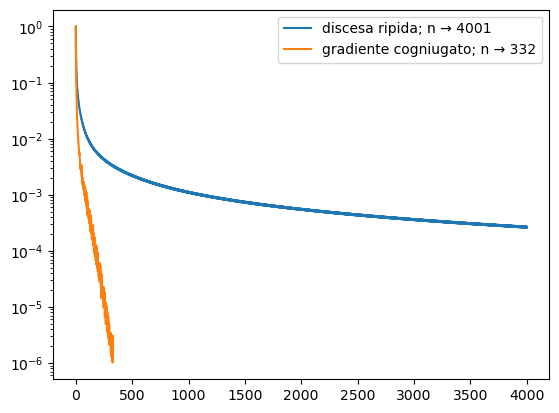

In [75]:
from itertools import takewhile
from numpy.linalg import norm

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def steep(A, b, dir, alfa, toll=1e-6, itmax=4000):
    x0 = np.zeros_like(b)
    r = A @ x0 - b
    err = lambda n, d: norm(n)/norm(d)

    stop_criteria = lambda i, args: i < itmax and err(args[1],b) > toll
    def passo(x, r, p):
        a = alfa(A, r, p)
        nr = r + a * (A.T @ p)
        return x+a*p, nr, dir(nr, r, p)

    iter = iterate(passo, (x0, r, -r))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]

    x_arr = [x for x, _, p in arr]
    return x_arr[-1], len(x_arr), [err(r, b) for _, r, p in arr]

def steepest(A, b):
    alfa = lambda A, r, p: -r.T @ p / (A.T @ p @ p)
    dir = lambda nr, r, p: -r
    return steep(A, b, dir, alfa)

def conj(A, b):
    alfa = lambda A, r, p: r.T @ r / (A.T @ p @ p)
    def dir(nr, r, p):
        gamma = (nr.T @ nr) / (r.T @ r)
        return -nr + (gamma * p)
        
    return steep(A, b, dir, alfa)


def display(A, b, method, name):
    _, it, err = method(A, b)
    plt.semilogy(range(it), err, label=name + f'; n → {it}')
    plt.legend()


display(A, b, steepest, 'discesa ripida')
display(A, b, conj, 'gradiente cogniugato')

 - Verificare se la matrice è  malcondizionata, dire teoricamente cosa questo implica in termini di velocità di  convergenza alla soluzione di ciascuno dei due metodi, richiamando il risultato teorico visto a lezione. [**Punti 2**]
   

In [78]:
print(f'Condizionameno di A → {lin.cond(A)}')
#Matrice mal condizionata
#Infatti con il primo metodo non si riesce a convergere alla soluzione 

Condizionameno di A → 10000.000000004271


 - Costruire la matrice A1, ottenuta a partire da A sommandole una matrice diagonale con elementi sulla
      diagonali tutti uguali a 0.05
   nel seguente modo:
   
   A1=A+np.eye(A.shape[0])*0.05
   
   e termine noto b1, costruito in maniera tale che la soluzione del sistema A1 x1 =b1 sia il vettore formato da tutti 1.  Risolvere il sistema lineare con matrice dei coefficienti A1 e termine noto b1, sia con il metodo del gradiente che con il metodo del gradiente coniugato. Osservare il numero di iterazioni eseguito da ciascun metodo e giustificare i risultati  [**Punti 2**]
  
   **Totale: Punti 11**
   

Condizionameno di A → 20.958083832335376


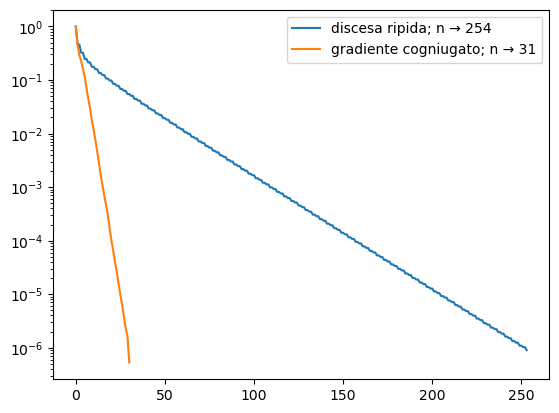

In [81]:
A1 = A + np.diag(np.ones_like(b) * 0.05)
b1 = A1 @ np.ones_like(b)

display(A1, b1, steepest, 'discesa ripida')
display(A1, b1, conj, 'gradiente cogniugato')
print(f'Condizionameno di A → {lin.cond(A1)}')
#Notiamo infatti che il condizionamento influisce sul numero di iterazioni di entrambi i metodi,
#Il metodo di discesa risente maggiormente dell'indice di condizionamento rispetto al gradiente cogniugato
#la quale si differienza per maggiore convenienza e efficienza riuscendo a raggiungere una buona
#convergenza per via del minor numero di moltiplicazione che deve fare ad ogni passo iterativo.

Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

## Esercizio 2 ##

Siano assegnati i numpy array

x =[1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0] 

y =[1.18,1.26,1.23,1.37,1.37,1.45,1.42,1.46,1.53,1.59,1.59] 
                                                               
contenenti rispettivamente le ascisse e le ordinate di 11 punti nel piano.                                                          

Scrivere lo script python in cui:

- si calcola il polinomio di approssimazione ai minimi quadrati di grado 1 dei punti assegnati, sviluppando le functions necessarie. e lo si valuti su 200 punti equidistanti nell'intervallo [1,3]  [**Punti: 4**]

In [3]:
from SolveTriangular import *

vander = lambda x, n: np.vander(x, increasing=True)[:,:n+1]

x = np.array([1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6,2.8,3.0])
y = np.array([1.18,1.26,1.23,1.37,1.37,1.45,1.42,1.46,1.53,1.59,1.59])


n = 1
A = vander(x, n)
print(f'Condizionamento di G → {lin.cond(A.T @ A)}\n')
#Usiamo qr in quanto per eqnorm il problema è mediamente condizionato

def qrLS(A, b):
    from numpy.linalg import matrix_rank as rank
    Q, R = splin.qr(A)
    R1 = R[:rank(A)]
    print(f'Condizionamento di R1 → {lin.cond(R1)}\n')
    h = Q.T @ b
    return Usolve(R1, h[:rank(A)])

def regression(x, y, n, method, name):
    A = vander(x, n)
    xv = np.linspace(min(x), max(x), 200)
    reg = method(A, y)
    return np.polyval(np.flip(reg), xv)

reg = regression(x, y, n, qrLS, 'qrLS')

Condizionamento di G → 70.88589282069798

Condizionamento di R1 → 8.419376035116738



- si calcola il polinomio di interpolazione dei punti assegnati sviluppando le functions necessarie e lo si valuti su 200 punti equidistanti nell'intervallo [1,3]  [**Punti: 4**]

In [4]:
def lagrange(xnodi, j):
    x = xnodi[xnodi != xnodi[j]]
    num = np.poly(x)
    return num / np.polyval(num, xnodi[j])

def interL(x, y, xv):
    L = np.array([np.polyval(lagrange(x, j), xv) for j, v in enumerate(x)])
    return L.T @ y

# x, y = np.array(x), np.array(y)
def learp(x, y):
    xv = np.linspace(min(x), max(x), 200)
    return interL(x, y, xv)

interp = learp(x, y)

- Si modifichino le ordinate dei punti assegnati, facendo uso della formula   $\hat{y_i}=2*x_i+1$, $i=1,...,11$, e si ricalcoli il polinomio interpolante ed il polinomio di approssimazione di grado 1, a partire dalle coppie $(x_i,\hat{y_i})$, $i=1,11$   [**Punti: 1**]

In [11]:
x1 = np.arange(1, 12)
y1 = y + 2*x1 + 1

reg1 = regression(x1, y1, n, qrLS, 'qrLS')
interp1 = learp(x1, y1)

Condizionamento di R1 → 14.795115126575825



- Si visualizzi in un grafico il polinomio interpolante, il polinomio di approssimazione di grado 1 ed i punti$(x_i,y_i)$, i=1,11 ed in un altro grafico il polinomio interpolante, il polinomio di approssimazione di grado 1 ed i $(x_i,\hat{y_i})$, $i=1,11$  [**Punti:1**]

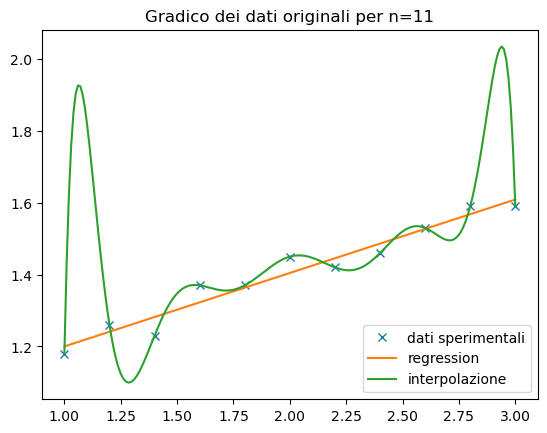

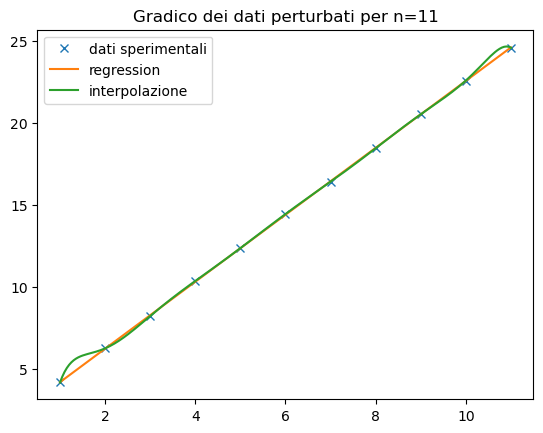

In [12]:
def plot_compare(reg, interp, x, y, name):
    xv = np.linspace(min(x), max(x), 200)
    plt.plot(x, y, 'x', label='dati sperimentali')
    plt.plot(xv, reg, label='regression')
    plt.plot(xv, interp, label='interpolazione')
    plt.title(name)
    plt.legend()
    plt.show()

plot_compare(reg, interp, x, y, f'Gradico dei dati originali per n={len(x)}')
plot_compare(reg1, interp1, x1, y1, f'Gradico dei dati perturbati per n={len(x)}')

- Si fornisca una spiegazione teorica dei risultati ottenuti
  [**Punti: 4**]

In [8]:
cond = lambda n: 2**(n+1) / n*np.log(n)
print(f'Condizionamento del problema n → {len(x1)}; LEB → {cond(len(x1))}')

print("\nL'interpolazione con nodi equispaziati fornisce fitte oscillazioni agli estremi dell'intervallo\n" \
      + "dovute all'irregolarita della funzione (primo caso). Dall'indice di condizionamento possiamo \nnotare che "\
      + "risulta abbastanza elevato e dunque l'amplificazione degli errori è maggiore")

Condizionamento del problema n → 11; LEB → 892.8890033983752

L'interpolazione con nodi equispaziati fornisce fitte oscillazioni agli estremi dell'intervallo
dovute all'irregolarita della funzione (primo caso). Dall'indice di condizionamento possiamo 
notare che risulta abbastanza elevato e dunque l'amplificazione degli errori è maggiore


                                                                        Totale 14 punti

## Domanda intelligenza artificiale

- Importanza del learning rate nell'allenamento di una rete neurale 
[**Punti: 1**]
- Illustra l'algoritmo di backpropagation per il calcolo delle derivate parziale della funzione costo rispetto ai pesi di tutti i layer, nel caso di una MLP con 1 nodo di input, 3 layer nascosti formati da un solo nodo, ed 1 nodo di output. [**Punti: 4**] 
 
- Tecniche di Ottimizzazione: metodo di discesa del gradient batch, metodo del gradiente stocastico (SGD) ,metodo del gradiente stocastico minibatch. [**Punti: 2**]


    [**Totale: punti 7**]
